<h1 align=center style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
در جست‌وجوی لبه
</font>
</h1>

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مقدمه
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این تمرین قصد داریم که بر روی یک تصویر لبه‌یابی را انجام دهیم. در این تمرین عملگرهای مختلفی را بررسی میکنیم و تاثیر آنها را بر تصویر بررسی میکنیم.
</font>
</p>

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله اول: وارد کردن عکس
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
ابتدا تصویر زیر را که در پوشه Data قرار دارد به شکل خاکستری وارد کنید. دقت کنید که حتما تصویر را بصورت خاکستری وارد نمایید.
    <br>
    Flower poster.jpg
</font>
</p>

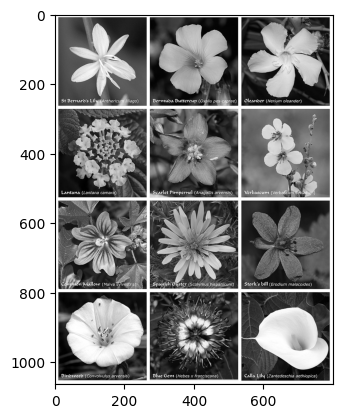

In [13]:
image = cv2.imread('Data/Flower poster.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله دوم: هموارسازی
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این مرحله نوبت به این می‌رسد که با استفاده از یک هسته گوسی بر روی تصویر ورودی هموارسازی را اعمال کنیم تا تصویر تاحدی تار شود. برای این کار هموارسازی گوسی خود را با پارامترهای زیر مقداردهی کنید:
</font>
</p>

$${kernel\:size} = 5\times5 $$
$${\sigma} = 1.0 $$

22.817309045081767


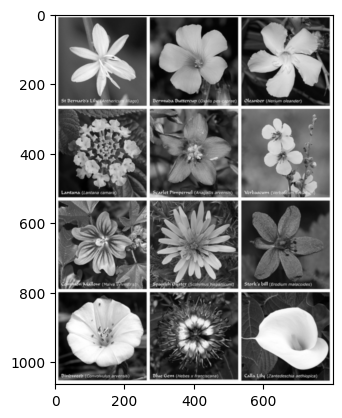

In [14]:
smooth_image = cv2.GaussianBlur(image, (5, 5), 1.0)
plt.imshow(cv2.cvtColor(smooth_image, cv2.COLOR_BGR2RGB))
print(cv2.PSNR(image, smooth_image))

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله سوم: محاسبه مشتق افقی و عمودی
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این مرحله می‌خواهیم که مشتق عمودی و افقی تصویر را محاسبه کنیم.
    <br>
    برای محاسبه مشتق افقی و عمودی می‌توانید فیلتر سوبل استفاده کنید. پارامترهای این فیلتر را به شکل زیر مقداردهی کنید.
    همچنین سپس باید گرادیان‌ها را ترکیب کنید(شدت مشتق‌ها) و جهت گرادیان‌ها(برحسب درجه) نیز محاسبه کنید.
</font>
</p>

$$ {kernel\:size} = 3\times3$$

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
 از این اطلاعات در ادامه استفاده خواهیم کرد. همچنین دقت کنید که با استفاده از تابع cv2.convertScaleAbs حتما مشتق افقی، مشتق عمودی و شدت گرادیان‌ها باید همگی نرمال‌سازی بشوند و سپس مابقی مراحل انجام شود.
    <br>
    همچنین نتیجه اعمال مشتق افقی، مشتق عمودی و شدت مشتق‌ها را فایل‌هایی با نام‌های زیر ذخیره کنید. توجه کنید که آنها را به شکل RGB ذخیره کنید.
    <br>
    x_gradient_flower.jpg
    <br>
    y_gradient_flower.jpg
        <br>
    magnitude_gradient_flower.jpg
</font>
</p>

True

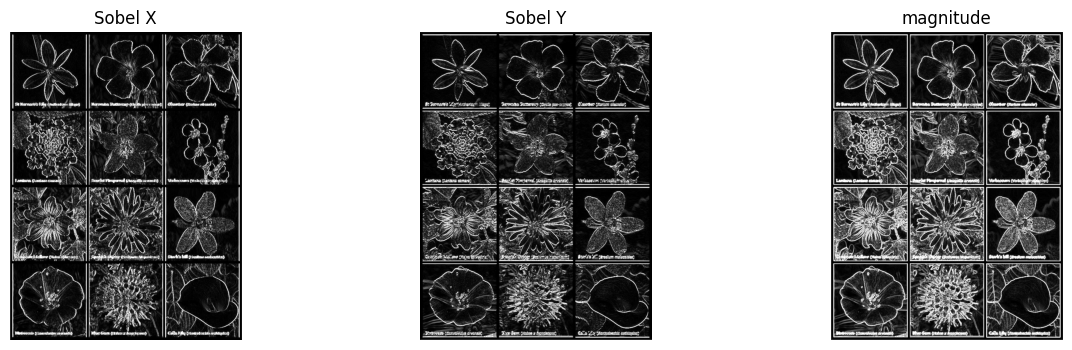

In [15]:
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

magnitude = cv2.magnitude(sobel_x, sobel_y)
direction = cv2.phase(sobel_x, sobel_y, angleInDegrees=True)

sobel_x = cv2.convertScaleAbs(sobel_x)
sobel_y = cv2.convertScaleAbs(sobel_y)
magnitude = cv2.convertScaleAbs(magnitude)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(cv2.cvtColor(sobel_x, cv2.COLOR_BGR2RGB))
axes[0].set_title("Sobel X")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(sobel_y, cv2.COLOR_BGR2RGB))
axes[1].set_title("Sobel Y")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(magnitude, cv2.COLOR_BGR2RGB))
axes[2].set_title("magnitude")
axes[2].axis("off")

cv2.imwrite('x_gradient_flower.jpg', cv2.cvtColor(sobel_x, cv2.COLOR_BGR2RGB))
cv2.imwrite('y_gradient_flower.jpg', cv2.cvtColor(sobel_y, cv2.COLOR_BGR2RGB))

In [16]:
submit_x_grad = cv2.imread('x_gradient_flower.jpg', cv2.IMREAD_GRAYSCALE)
# submit_x_grad = cv2.convertScaleAbs(submit_x_grad)
print(cv2.PSNR(sobel_x, submit_x_grad))


submit_y_grad = cv2.imread('y_gradient_flower.jpg', cv2.IMREAD_GRAYSCALE)
# submit_y_grad = cv2.convertScaleAbs(submit_y_grad)
print(cv2.PSNR(sobel_y, submit_y_grad))

submit_magnitude = cv2.imread('magnitude_gradient_flower.jpg', cv2.IMREAD_GRAYSCALE)
# submit_magnitude = cv2.convertScaleAbs(submit_magnitude)
print(cv2.PSNR(magnitude, submit_magnitude))

44.012097730997155
43.93407553411087
43.91143183173394


<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله چهارم: اعمال سرکوب غیر حداکثری
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در سلول زیر تابعی تعریف شده است که سرکوب غیر حداکثری را انجام میدهد. ورودی این تابع، شدت مشتق و جهت مشتق محاسبه شده در مرحله قبل می‌باشد. 
</font>
</p>

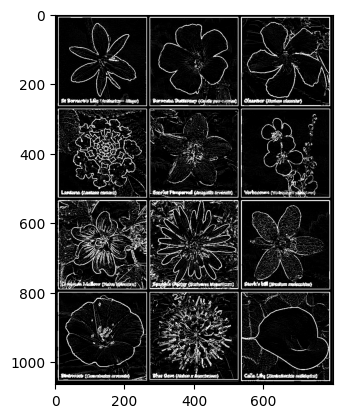

In [17]:
def non_maximum_suppression(gradient_magnitude, gradient_direction):
    height, width = gradient_magnitude.shape
    suppressed = np.zeros((height, width), dtype=np.uint8)

    angle = gradient_direction

    for i in range(1, height - 1):
        for j in range(1, width - 1):
            q, r = 255, 255

            if (0 <= angle[i, j] < 22.5) or (157.5 <= angle[i, j] <= 180):
                q = gradient_magnitude[i, j + 1]
                r = gradient_magnitude[i, j - 1]
            elif 22.5 <= angle[i, j] < 67.5:
                q = gradient_magnitude[i + 1, j - 1]
                r = gradient_magnitude[i - 1, j + 1]
            elif 67.5 <= angle[i, j] < 112.5:
                q = gradient_magnitude[i + 1, j]
                r = gradient_magnitude[i - 1, j]
            elif 112.5 <= angle[i, j] < 157.5:
                q = gradient_magnitude[i - 1, j - 1]
                r = gradient_magnitude[i + 1, j + 1]

            if (gradient_magnitude[i, j] >= q) and (gradient_magnitude[i, j] >= r):
                suppressed[i, j] = gradient_magnitude[i, j]

    return suppressed

nms = non_maximum_suppression(gradient_magnitude=magnitude, gradient_direction=direction)
plt.imshow(cv2.cvtColor(nms, cv2.COLOR_BGR2RGB))

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله پنجم: اعمال هیسترزیس
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این سلول هیسترزیس را پیاده‌سازی کنید. این پیاده‌سازی را بر روی خروجی سرکوب غیر حداکثری اعمال کنید تا لبه‌های قوی و لبه‌های ضعیف حفظ شوند و نویز از تصویر خارج شود.
میتواند مقدار لبه‌های قوی را  با شدت 255 جایگزین کنید و لبه‌های ضعیف را با شدت 50 .
    <br>
     مقدار آستانه‌های بالا و پائین را به شکل زیر در نظر بگیرید.
</font>
</p>

$${T_1} = 100 $$
$${T_2} = 200 $$

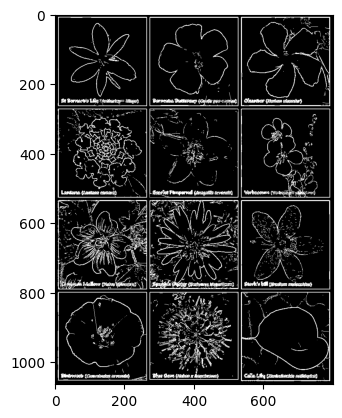

In [18]:
def hysteresis(img, low_thresh, high_thresh):

    strong = 255
    weak = 50

    strong_edges = img >= high_thresh
    weak_edges = (img >= low_thresh) & (img < high_thresh)

    output = np.zeros_like(img, dtype=np.uint8)

    output[strong_edges] = strong
    output[weak_edges] = weak

    height, width = img.shape
    for i in range(1, height - 1):
        for j in range(1, width - 1):
            if output[i, j] == weak:
                if strong in output[i-1:i+2, j-1:j+2]:
                    output[i, j] = strong
                else:
                    output[i, j] = 0

    return output

hysteresis_output = hysteresis(nms, low_thresh=100, high_thresh=200)
plt.imshow(cv2.cvtColor(hysteresis_output, cv2.COLOR_BGR2RGB))

In [27]:
original_hystersis = hysteresis_output
import_hystersis = cv2.imread('canny_edge_flower.jpg', cv2.IMREAD_GRAYSCALE)
cv2.PSNR(original_hystersis, import_hystersis)

49.4412452030027

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله ششم: ذخیره‌سازی
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
    شما موفق شدید که لبه‌یابی را بطور کامل انجام دهید. مراحلی که طی کردید، در اصل پیاده‌سازی روش کنی برای تشخیص لبه بود. حال باید تصویر حاصل در مرحله قبل را ذخیره کنید. این فایل را بصورت RGB باید ذخیره کنید و نام آن بصورت زیر باشد:
    <br>
    canny_edge_flower.jpg
</font>
</p>

In [20]:
cv2.imwrite('canny_edge_flower.jpg', cv2.cvtColor(hysteresis_output, cv2.COLOR_BGR2RGB))

True

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله هفتیم: سلول جواب‌ساز
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
بدون هیچگونه تغییری، این سلول را اجرا کنید تا فایل پاسخ شما آماده شود.
</font>
</p>

In [ ]:
import zipfile

def compress(file_names):
    print("File Paths:")
    print(file_names)
    # Select the compression mode ZIP_DEFLATED for compression
    # or zipfile.ZIP_STORED to just store the file
    compression = zipfile.ZIP_DEFLATED
    # create the zip file first parameter path/name, second mode
    with zipfile.ZipFile("result.zip", mode="w") as zf:
        for file_name in file_names:
            # Add file to the zip file
            # first parameter file to zip, second filename in zip
            zf.write('./' + file_name, file_name, compress_type=compression)


file_names = ["notebook.ipynb", "x_gradient_flower.jpg", "y_gradient_flower.jpg", 
            "magnitude_gradient_flower.jpg", "canny_edge_flower.jpg"]
compress(file_names)

File Paths:
['notebook.ipynb', 'x_gradient_flower.jpg', 'x_gradient_flower.jpg', 'y_gradient_flower.jpg', 'magnitude_gradient_flower.jpg', 'canny_edge_flower.jpg']


c:\ProgramData\anaconda3\Lib\zipfile.py:1550: UserWarning: Duplicate name: 'x_gradient_flower.jpg'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
